# Module 11 · Các phân bố xác suất thường gặp

**Nguồn sách:** Barkat, chương 2, tr. 75–139

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """In một kết quả có tên, bỏ các số 0 thừa ở cuối (trang web đọc các dòng bắt đầu bằng ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Phân bố rời rạc
🎯 **Phương pháp này trả lời câu hỏi gì?** Các công thức nhị thức, đa thức, hình học, Pascal, siêu bội, Poisson và giới hạn có khớp với hàm khối của thư viện và với mô phỏng?

In [2]:
from math import comb, factorial, gamma as G, sqrt, pi, exp, log
from scipy import stats, special, integrate
rg = np.random.default_rng(11)
trap = getattr(np, "trapezoid", None) or np.trapz
# nhị thức
p10 = comb(10, 2)*(1/6)**2*(5/6)**8
assert abs(p10 - stats.binom.pmf(2, 10, 1/6)) < 1e-14 and abs(np.mean(rg.binomial(10, 1/6, 400000) == 2) - p10) < 0.003
report("bi_ex21", p10, ".4f")
c2 = sum(comb(3, k)*0.8**k*0.2**(3 - k) for k in (2, 3))
assert abs(c2 - 0.896) < 1e-12 and abs(np.mean(rg.binomial(3, 0.8, 400000) >= 2) - c2) < 0.003
report("bi_ex22", c2, ".3f")
report("bi_mean", 10/6, ".4f"); report("bi_var", 10*(1/6)*(5/6), ".4f")
assert abs(stats.binom.var(10, 1/6) - 10*(1/6)*(5/6)) < 1e-14
# đa thức
mn = factorial(10)/(factorial(2)*factorial(3)*factorial(5))*0.2**2*0.3**3*0.5**5
assert abs(mn - stats.multinomial.pmf([2, 3, 5], 10, [0.2, 0.3, 0.5])) < 1e-14
report("mn_p", mn, ".4f")
# hình học, Pascal
pg = (5/6)**2*(1/6)
assert abs(pg - stats.geom.pmf(3, 1/6)) < 1e-14
kk = np.arange(1, 4000); gm = np.sum(kk*(5/6)**(kk - 1)/6); gv = np.sum(kk**2*(5/6)**(kk - 1)/6) - gm**2
assert abs(gm - 6) < 1e-9 and abs(gv - 30) < 1e-6
report("ge_p3", pg, ".4f"); report("ge_mean", gm, ".0f"); report("ge_var", gv, ".0f")
pp = comb(4, 2)*0.5**3*0.5**2
assert abs(pp - stats.nbinom.pmf(2, 3, 0.5)) < 1e-14          # nbinom: số thất bại x = k − r
report("pa_p", pp, ".4f")
n_, r_, p_ = 10, 3, 0.3
lhs = stats.binom.sf(r_ - 1, n_, p_); rhs = stats.nbinom.cdf(n_ - r_, r_, p_)
assert abs(lhs - rhs) < 1e-14
report("pa_rel", lhs, ".4f")
# siêu bội
hy = comb(5, 3)*comb(6, 4)/comb(11, 7)
assert abs(hy - stats.hypergeom.pmf(3, 11, 5, 7)) < 1e-14 and abs(hy - 5/11) < 1e-14
hv = 7*5*6*4/(121*10)
assert abs(stats.hypergeom.var(11, 5, 7) - hv) < 1e-12
report("hy_p", hy, ".4f"); report("hy_var", hv, ".4f")
hd = abs(stats.hypergeom.pmf(3, 10000, 3000, 10) - stats.binom.pmf(3, 10, 0.3))
assert hd < 1e-3
report("hy_dev", hd, ".1e")
# Poisson
lam = 3.0
ms = lam**2 + lam
kk = np.arange(0, 80); pm = stats.poisson.pmf(kk, lam)
assert abs(np.sum(kk**2*pm) - ms) < 1e-9
report("po_ms", ms, ".0f")
conv = np.convolve(stats.poisson.pmf(np.arange(0, 60), 2), stats.poisson.pmf(np.arange(0, 60), 3))[5]
assert abs(conv - stats.poisson.pmf(5, 5)) < 1e-12
report("po_add", conv, ".4f")
pb = stats.binom.pmf(2, 1000, 0.003); pw = stats.poisson.pmf(2, 3.0)
assert abs(pb - pw) < 5e-3 and abs(pb - comb(1000, 2)*0.003**2*0.997**998) < 1e-14
report("po_bin", pb, ".4f"); report("po_pois", pw, ".4f"); report("po_dev", abs(pb - pw), ".1e")

▸ bi_ex21 = 0.2907
▸ bi_ex22 = 0.896
▸ bi_mean = 1.6667
▸ bi_var = 1.3889
▸ mn_p = 0.0851
▸ ge_p3 = 0.1157
▸ ge_mean = 6
▸ ge_var = 30
▸ pa_p = 0.1875
▸ pa_rel = 0.6172
▸ hy_p = 0.4545
▸ hy_var = 0.6942
▸ hy_dev = 1.3e-04
▸ po_ms = 12
▸ po_add = 0.1755
▸ po_bin = 0.2242
▸ po_pois = 0.224
▸ po_dev = 1.1e-04


#### 📤 Đầu ra thật
Nhị thức: 0.2907, 0.896, trung bình 1.6667, phương sai 1.3889; đa thức 0.0851. Hình học: 0.1157, 6, 30; Pascal 0.1875, quan hệ 0.6172. Siêu bội: 0.4545, 0.6942, lệch tới nhị thức 1.3e-04. Poisson: 12, cộng 0.1755; nhị thức 0.2242 so với 0.224 (lệch 1.1e-04).

## 2. Đều, chuẩn, mũ, gamma, beta
🎯 **Phương pháp này trả lời câu hỏi gì?** Các ví dụ 2.5, bài 2.11, 2.12 và các công thức mômen cho đều, mũ, Laplace, gamma, beta có đúng, và xấp xỉ chuẩn tốt cỡ nào?

In [3]:
# đều
a_, b_ = 2.0, 8.0
uv = integrate.quad(lambda x: (x - 5)**2/(b_ - a_), a_, b_)[0]
assert abs(uv - 3) < 1e-12
report("un_var", uv, ".0f")
# chuẩn
Qf = lambda x: 0.5*special.erfc(x/np.sqrt(2))
assert abs(Qf(0.5) - stats.norm.sf(0.5)) < 1e-15
p1 = Qf(0.5); p2 = stats.norm.cdf(1.0) - stats.norm.cdf(-0.5)
assert abs(p1 - stats.norm.sf(4, 3, 2)) < 1e-15 and abs(p2 - (stats.norm.cdf(5, 3, 2) - stats.norm.cdf(2, 3, 2))) < 1e-15
Ys = rg.normal(3, 2, 1000000)
assert abs(np.mean(Ys > 4) - p1) < 3e-3 and abs(np.mean((Ys > 2) & (Ys < 5)) - p2) < 3e-3
report("n_ex25", p1, ".4f"); report("n_ex25b", p2, ".4f")
q4 = Qf(4.0); q4a = np.exp(-8)/(4*np.sqrt(2*np.pi))
assert abs(q4 - stats.norm.sf(4)) < 1e-18 and 0.9 < q4a/q4 < 1.1
report("n_q4", q4, ".3e"); report("n_q4a", q4a, ".3e")
m4 = integrate.quad(lambda x: x**4*stats.norm.pdf(x), -12, 12)[0]
assert abs(m4 - 3) < 1e-8 and abs(factorial(4)/(factorial(2)*2**2) - 3) < 1e-14
report("n_m4", m4, ".0f")
# bài 2.11, 2.12
ex211 = stats.binom.sf(39, 200, 1/6)
mu, sd = 200/6, np.sqrt(200*(1/6)*(5/6))
nap211 = stats.norm.sf((39.5 - mu)/sd)
mc211 = np.mean(rg.binomial(200, 1/6, 1000000) >= 40)
assert abs(ex211 - mc211) < 2e-3 and abs(ex211 - nap211) < 0.02
report("c211_ex", ex211, ".4f"); report("c211_n", nap211, ".4f")
ex212 = stats.poisson.sf(5, 3.2)
nap212 = stats.norm.sf((5.5 - 3.2)/np.sqrt(3.2))
mc212 = np.mean(rg.poisson(0.032, (200000, 100)).sum(axis=1) > 5)
assert abs(ex212 - mc212) < 3e-3 and abs(ex212 - nap212) < 0.03
report("c212_ex", ex212, ".4f"); report("c212_n", nap212, ".4f")
# mũ, không nhớ; Laplace
al, x1, x2 = 2.0, 0.5, 0.7
lhs = np.exp(-al*(x1 + x2))/np.exp(-al*x1); rhs = np.exp(-al*x2)
assert abs(lhs - rhs) < 1e-15
Ex = rg.exponential(1/al, 2000000)
assert abs(np.mean(Ex[Ex > x1] >= x1 + x2) - rhs) < 3e-3
report("ex_mem", rhs, ".4f")
lv = integrate.quad(lambda x: x*x*0.5*np.exp(-abs(x)), -60, 60, points=[0])[0]
assert abs(lv - 2) < 1e-8
report("la_var", lv, ".0f")
# gamma, beta
gm = integrate.quad(lambda x: x*stats.gamma.pdf(x, 3, scale=2), 0, np.inf)[0]
gv = integrate.quad(lambda x: x*x*stats.gamma.pdf(x, 3, scale=2), 0, np.inf)[0] - gm**2
assert abs(gm - 6) < 1e-8 and abs(gv - 12) < 1e-6 and abs(G(0.5)**2 - pi) < 1e-12
report("ga_mean", gm, ".0f"); report("ga_var", gv, ".0f"); report("ga_half", G(0.5), ".4f")
Bf = G(2)*G(5)/G(7)
bm = integrate.quad(lambda x: x*x**1*(1 - x)**4/Bf, 0, 1)[0]; bv = integrate.quad(lambda x: x*x*x**1*(1 - x)**4/Bf, 0, 1)[0] - bm**2
Bs = rg.beta(2, 5, 1000000)
assert abs(Bf - special.beta(2, 5)) < 1e-14 and abs(bm - 2/7) < 1e-9 and abs(bv - 10/(49*8)) < 1e-9 and abs(np.var(Bs) - bv) < 2e-4
report("be_mean", bm, ".4f"); report("be_var", bv, ".4f")

▸ un_var = 3
▸ n_ex25 = 0.3085
▸ n_ex25b = 0.5328
▸ n_q4 = 3.167e-05
▸ n_q4a = 3.346e-05
▸ n_m4 = 3
▸ c211_ex = 0.1223
▸ c211_n = 0.121
▸ c212_ex = 0.1054
▸ c212_n = 0.0993


▸ ex_mem = 0.2466
▸ la_var = 2
▸ ga_mean = 6
▸ ga_var = 12
▸ ga_half = 1.7725


▸ be_mean = 0.2857
▸ be_var = 0.0255


#### 📤 Đầu ra thật
Đều: 3. Chuẩn: 0.3085, 0.5328, $Q(4)$ = 3.167e-05 (xấp xỉ 3.346e-05), $E[X^4]$ = 3. Bài 2.11: 0.1223 và 0.121; bài 2.12: 0.1054 và 0.0993. Mũ: 0.2466; Laplace 2; gamma 6, 12, $\Gamma(1/2)$ = 1.7725; beta 0.2857, 0.0255.

## 3. Chi bình phương, Rayleigh, Rice, Maxwell, Nakagami, Student, Cauchy
🎯 **Phương pháp này trả lời câu hỏi gì?** Chuỗi biến đổi từ biến chuẩn có cho đúng các phân bố và tham số, kể cả hàm Marcum của Rice, Nakagami từ mômen, và tính bất thường của Cauchy? Mỗi số kiểm bằng mô phỏng và bằng tích phân hoặc công thức.

In [4]:
# chi bình phương
Z = rg.standard_normal((1000000, 4))
X2 = (Z**2).sum(axis=1)
assert abs(np.mean(X2) - 4) < 0.02 and abs(np.var(X2) - 8) < 0.1 and abs(stats.gamma.var(2, scale=2) - 8) < 1e-12
report("chi_mean", stats.chi2.mean(4), ".0f"); report("chi_var", stats.chi2.var(4), ".0f")
# không tâm n = 3, σ = 1, λ = 5
mvec = np.array([np.sqrt(5), 0, 0])
Xn = ((rg.standard_normal((1000000, 3)) + mvec)**2).sum(axis=1)
assert abs(np.mean(Xn) - 8) < 0.03 and abs(np.var(Xn) - 26) < 0.4 and abs(stats.ncx2.mean(3, 5) - 8) < 1e-12 and abs(stats.ncx2.var(3, 5) - 26) < 1e-12
report("nc_mean", 8, ".0f"); report("nc_var", 26, ".0f")
# Rayleigh σ = 1
Rr = np.sqrt((rg.standard_normal((1000000, 2))**2).sum(axis=1))
rmn = integrate.quad(lambda y: y*y*np.exp(-y*y/2), 0, np.inf)[0]; rvv = integrate.quad(lambda y: y**3*np.exp(-y*y/2), 0, np.inf)[0] - rmn**2
assert abs(rmn - np.sqrt(np.pi/2)) < 1e-9 and abs(rvv - (2 - np.pi/2)) < 1e-9 and abs(np.mean(Rr) - rmn) < 3e-3
report("ray_mean", rmn, ".4f"); report("ray_var", rvv, ".4f"); report("ray_F1", 1 - np.exp(-0.5), ".4f")
assert abs(np.mean(Rr <= 1) - (1 - np.exp(-0.5))) < 3e-3
vy = np.var(2*Rr**2)
assert abs(vy - 16) < 0.4 and abs(stats.expon.var(scale=2)*4 - 16) < 1e-12        # X² ~ mũ trung bình 2σ²
report("ray_vy", 16, ".0f")
polar = integrate.dblquad(lambda r, th: r*np.exp(-r*r/2)/(2*np.pi), 0, 2*np.pi, 0, 2)[0]
assert abs(polar - (1 - np.exp(-2))) < 1e-9 and abs(np.mean(Rr <= 2) - polar) < 3e-3
report("ray_polar", polar, ".4f"); report("ray_tail", np.exp(-0.5), ".4f")
# Rice m1 = m2 = 1, σ = 1, λ = 2
lam = 2.0
Rc = np.sqrt(((rg.standard_normal((1000000, 2)) + 1.0)**2).sum(axis=1))
f_rice = lambda r: r*np.exp(-(r - np.sqrt(lam))**2/2)*special.i0e(np.sqrt(lam)*r)
F_int = integrate.quad(f_rice, 0, 2)[0]
F_ncx = stats.ncx2.cdf(4.0, 2, lam)                       # P(R ≤ 2) = P(R² ≤ 4), R² ~ ncx2(2, λ)
F_rice = stats.rice.cdf(2.0, np.sqrt(lam))
assert abs(F_int - F_ncx) < 1e-9 and abs(F_int - F_rice) < 1e-9 and abs(np.mean(Rc <= 2) - F_int) < 3e-3
Emean = integrate.quad(lambda r: r*f_rice(r), 0, 60)[0]
assert abs(Emean - np.mean(Rc)) < 5e-3
report("rice_F", F_int, ".4f"); report("rice_mean", Emean, ".4f")
# Maxwell σ = 1
Mx = np.sqrt((rg.standard_normal((1000000, 3))**2).sum(axis=1))
fm = lambda y: np.sqrt(2/np.pi)*y*y*np.exp(-y*y/2)
mm = integrate.quad(lambda y: y*fm(y), 0, np.inf)[0]; mv = integrate.quad(lambda y: y*y*fm(y), 0, np.inf)[0] - mm**2
assert abs(mm - 2*np.sqrt(2/np.pi)) < 1e-9 and abs(mv - (3 - 8/np.pi)) < 1e-9 and abs(np.mean(Mx) - mm) < 4e-3
report("mx_mean", mm, ".4f"); report("mx_var", mv, ".4f")
# Nakagami m = 2, v = 1: X² ~ gamma(m, v/m)
mN, vN = 2.0, 1.0
Xk = np.sqrt(rg.gamma(mN, vN/mN, 1000000))
v_hat = np.mean(Xk**2); m_hat = v_hat**2/np.var(Xk**2)
fN = lambda x: 2/G(mN)*(mN/vN)**mN*x**(2*mN - 1)*np.exp(-mN*x*x/vN)
assert abs(integrate.quad(fN, 0, np.inf)[0] - 1) < 1e-9 and abs(m_hat - 2) < 0.05 and abs(v_hat - 1) < 3e-3
assert abs(stats.nakagami.mean(mN, scale=np.sqrt(vN)) - np.mean(Xk)) < 3e-3
report("nk_m", m_hat, ".2f"); report("nk_v", v_hat, ".2f"); report("nk_int", integrate.quad(fN, 0, np.inf)[0], ".0f")
# Student, F, Cauchy
tS = rg.standard_normal(1000000)/np.sqrt(rg.chisquare(5, 1000000)/5)
assert abs(np.var(tS[np.abs(tS) < 200]) - 5/3) < 0.1 and abs(stats.t.var(5) - 5/3) < 1e-12
report("t_var", 5/3, ".4f")
Fs = (rg.chisquare(4, 1000000)/4)/(rg.chisquare(10, 1000000)/10)
assert abs(np.mean(Fs) - 1.25) < 0.02 and abs(stats.f.mean(4, 10) - 1.25) < 1e-12
report("f_mean", 1.25, ".2f")
t1 = stats.t.cdf(1, 1) - stats.t.cdf(-1, 1); assert abs(t1 - 0.5) < 1e-12 and abs(t1 - (stats.cauchy.cdf(1) - stats.cauchy.cdf(-1))) < 1e-12
report("t1_p", t1, ".2f")
def prob_mean(n):
    xs = rg.standard_cauchy((100000, n)).mean(axis=1); return np.mean(np.abs(xs) < 1)
assert abs(prob_mean(1) - 0.5) < 5e-3 and abs(prob_mean(100) - 0.5) < 5e-3
pn = np.mean(np.abs(rg.standard_normal((100000, 100)).mean(axis=1)) < 1)
assert pn > 0.999
report("cau_1", 0.5, ".2f"); report("cau_100", 0.5, ".2f"); report("cau_n100", stats.norm.cdf(10) - stats.norm.cdf(-10), ".0f")
csum = rg.standard_cauchy((1000000, 2)).sum(axis=1)
assert abs(np.mean(np.abs(csum) < 2) - 0.5) < 3e-3 and abs(stats.cauchy.cdf(2, scale=2) - stats.cauchy.cdf(-2, scale=2) - 0.5) < 1e-12
report("cau_sum", 0.5, ".2f")

▸ chi_mean = 4
▸ chi_var = 8
▸ nc_mean = 8
▸ nc_var = 26
▸ ray_mean = 1.2533
▸ ray_var = 0.4292
▸ ray_F1 = 0.3935
▸ ray_vy = 16
▸ ray_polar = 0.8647
▸ ray_tail = 0.6065
▸ rice_F = 0.6057
▸ rice_mean = 1.8129
▸ mx_mean = 1.5958
▸ mx_var = 0.4535
▸ nk_m = 2
▸ nk_v = 1
▸ nk_int = 1
▸ t_var = 1.6667


▸ f_mean = 1.25
▸ t1_p = 0.5


▸ cau_1 = 0.5
▸ cau_100 = 0.5
▸ cau_n100 = 1
▸ cau_sum = 0.5


#### 📤 Đầu ra thật
Chi bình phương: 4, 8; không tâm 8, 26. Rayleigh: 1.2533, 0.4292, $F(\sigma)$ = 0.3935, $Y=2X^2$: 16, cực: 0.8647. Rice: $F_R(2)$ = 0.6057, trung bình 1.8129. Maxwell: 1.5958, 0.4535. Nakagami: $m$ = 2, $v$ = 1. $t_5$: 1.6667; $F$: 1.25; Cauchy: 0.5 và 0.5 so với chuẩn 1.

## 4. Gauss nhiều chiều, Weibull, log-chuẩn, K
🎯 **Phương pháp này trả lời câu hỏi gì?** Phân bố điều kiện, elip và trị riêng của Gauss hai chiều, các mômen của Weibull và log-chuẩn, và phân bố K từ tích speckle nhân texture có đúng công thức Bessel?

In [5]:
# Gauss hai chiều
m = np.array([1.0, -1.0]); s1, s2, rho = 1.0, 2.0, 0.6
Cm = np.array([[s1**2, rho*s1*s2], [rho*s1*s2, s2**2]])
cm = m[1] + rho*s2/s1*(2.0 - m[0]); cv = s2**2*(1 - rho**2)
XY = rg.multivariate_normal(m, Cm, 4000000)
sel = np.abs(XY[:, 0] - 2.0) < 0.02
assert abs(np.mean(XY[sel, 1]) - cm) < 0.03 and abs(np.var(XY[sel, 1]) - cv) < 0.08
report("bg_cm", cm, ".1f"); report("bg_cv", cv, ".2f")
det = np.linalg.det(Cm); assert abs(det - s1**2*s2**2*(1 - rho**2)) < 1e-12
f0_scalar = 1/(2*np.pi*s1*s2*np.sqrt(1 - rho**2)); f0_matrix = stats.multivariate_normal(m, Cm).pdf(m)
assert abs(f0_scalar - f0_matrix) < 1e-14
report("bg_det", det, ".2f"); report("bg_f0", f0_scalar, ".4f")
# không tương quan ⇒ độc lập
C0 = np.diag([s1**2, s2**2]); g0 = stats.multivariate_normal(m, C0)
grid = np.random.default_rng(3).uniform(-4, 4, (2000, 2)) + m
ind_dev = np.max(np.abs(g0.pdf(grid) - stats.norm.pdf(grid[:, 0], m[0], s1)*stats.norm.pdf(grid[:, 1], m[1], s2)))
assert ind_dev < 1e-15
report("bg_ind", max(ind_dev, 1e-17), ".0e")
# elip: công thức 2.226–2.229 và trị riêng
th = 0.5*np.arctan(2*rho*s1*s2/(s1**2 - s2**2))
su2 = (s1**2*np.cos(th)**2 - s2**2*np.sin(th)**2)/(np.cos(th)**2 - np.sin(th)**2)
sv2 = (s2**2*np.cos(th)**2 - s1**2*np.sin(th)**2)/(np.cos(th)**2 - np.sin(th)**2)
w = np.sort(np.linalg.eigvalsh(Cm))
assert abs(su2 - w[0]) < 1e-12 and abs(sv2 - w[1]) < 1e-12
report("bg_theta", np.degrees(th), ".2f"); report("bg_su", su2, ".3f"); report("bg_sv", sv2, ".3f")
# Weibull
wr = integrate.quad(lambda x: x*2*0.5*x*np.exp(-0.5*x*x), 0, np.inf)[0]
assert abs(wr - stats.weibull_min.mean(2, scale=np.sqrt(2))) < 1e-9 and abs(wr - np.sqrt(np.pi/2)) < 1e-9
w3m = G(1 + 1/3); w3v = G(1 + 2/3) - G(1 + 1/3)**2
assert abs(w3m - stats.weibull_min.mean(3)) < 1e-12 and abs(w3v - stats.weibull_min.var(3)) < 1e-12
report("wb_rmean", wr, ".4f"); report("wb_m3", w3m, ".4f"); report("wb_v3", w3v, ".4f")
# log-chuẩn
sg = 0.5
lm = np.exp(sg**2/2); lv = np.exp(sg**2)*(np.exp(sg**2) - 1)
Ln = np.exp(rg.normal(0, sg, 2000000))
assert abs(lm - stats.lognorm.mean(sg)) < 1e-12 and abs(lv - stats.lognorm.var(sg)) < 1e-12 and abs(np.mean(Ln) - lm) < 3e-3 and abs(np.var(Ln) - lv) < 1e-2
report("ln_mean", lm, ".4f"); report("ln_var", lv, ".4f")
# K: b = 1, ν = 2
b_, nu = 1.0, 2.0
fT = lambda t: 2/(b_**nu*G(nu))*t**(2*nu - 1)*np.exp(-t*t/b_**2)
fXT = lambda x, t: 2*x/t**2*np.exp(-x*x/t**2)
compound = integrate.quad(lambda t: fXT(1.0, t)*fT(t), 0, np.inf)[0]
bessel = 4/(b_*G(nu))*(1.0/b_)**nu*special.kv(nu - 1, 2*1.0/b_)
assert abs(compound - bessel) < 1e-7
tot = integrate.quad(lambda x: 4/(b_*G(nu))*(x/b_)**nu*special.kv(nu - 1, 2*x/b_), 0, np.inf)[0]
assert abs(tot - 1) < 1e-7
T = np.sqrt(rg.gamma(nu, b_**2, 2000000)); Sx = np.sqrt(rg.exponential(1.0, 2000000))*T
assert abs(np.mean(Sx**2) - nu*b_**2) < 0.03 and abs(np.mean(T**2) - nu*b_**2) < 0.03
report("k_f1", bessel, ".4f"); report("k_e2", nu*b_**2, ".0f")

▸ bg_cm = 0.2
▸ bg_cv = 2.56
▸ bg_det = 2.56
▸ bg_f0 = 0.0995
▸ bg_ind = 3e-17
▸ bg_theta = -19.33
▸ bg_su = 0.579
▸ bg_sv = 4.421
▸ wb_rmean = 1.2533
▸ wb_m3 = 0.893
▸ wb_v3 = 0.1053
▸ ln_mean = 1.1331
▸ ln_var = 0.3647
▸ k_f1 = 0.5595
▸ k_e2 = 2


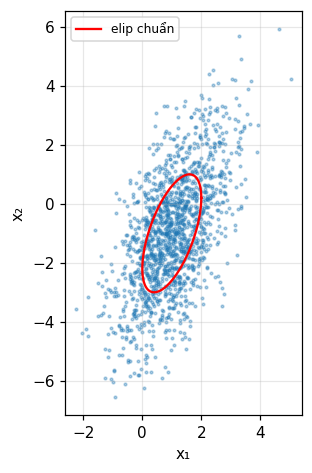

In [6]:
th_ = np.linspace(0, 2*np.pi, 300)
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(XY[:1500, 0], XY[:1500, 1], s=3, alpha=0.35)
L = np.linalg.cholesky(Cm)
el = (L @ np.vstack([np.cos(th_), np.sin(th_)])).T + m
ax.plot(el[:, 0], el[:, 1], "r", label=("elip chuẩn"))
ax.set_aspect("equal"); ax.legend(fontsize=8); ax.set_xlabel("x₁"); ax.set_ylabel("x₂"); plt.tight_layout(); plt.show()

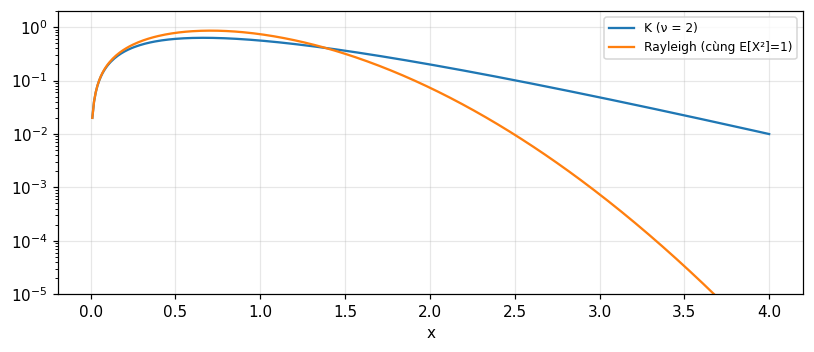

In [7]:
xs_ = np.linspace(0.01, 4, 400)
fig, ax = plt.subplots(figsize=(7.5, 3.3))
ax.semilogy(xs_, 4/(b_*G(nu))*(xs_/b_)**nu*special.kv(nu - 1, 2*xs_/b_), label=("K (ν = 2)"))
ax.semilogy(xs_, 2*xs_*np.exp(-xs_**2)*1, label=("Rayleigh (cùng E[X²]=1)"))
ax.set_ylim(1e-5, 2); ax.set_xlabel("x"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Gauss hai chiều: trung bình điều kiện 0.2, phương sai 2.56, $|C|$ = 2.56, $f(m)$ = 0.0995, độc lập khi $\rho=0$ lệch 3e-17; $\theta$ = -19.33 độ, $\sigma_u^2$ = 0.579, $\sigma_v^2$ = 4.421. Weibull: 1.2533, 0.893, 0.1053. Log-chuẩn: 1.1331, 0.3647. K: $f(1)$ = 0.5595, $E[X^2]$ = 2.